# Exercise 6: Normalizing Flows
## Submission date: 30\06\2026, 23:59.

Submitted by:

 **Saly Jammal - 212869259**
 
 **Or Dinar - 207035809**

## Configurations and initializations
This section loads libraries and configurations for various tasks for this course, it also contains utility functions used in the previous exercise about VAEs.

In [9]:
## Standard libraries
import os
import math
import random
import numpy as np
import pandas as pd
from collections import defaultdict

## Imports for plotting
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
%matplotlib inline
# from IPython.display import set_matplotlib_formats
# %config InlineBackend.figure_formats = ['svg', 'pdf']
from matplotlib.colors import to_rgb
import seaborn as sns

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"

# Path to the folder where the models are saved
CHECKPOINT_PATH = "./"

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)

Using device cuda:0


<Figure size 640x480 with 0 Axes>

In [10]:
class ContinuousRepresentation(object):
    def __call__(self, tensor):
        tensor = tensor * 255.0 
        noise = torch.rand_like(tensor) # Normal noise
        tensor = (tensor + noise) / 256.0
        return tensor

transform = transforms.Compose([
    transforms.ToTensor(),
    ContinuousRepresentation()
])

In [11]:
# Loading the training dataset. We need to split it into a training and validation part
train_dataset = MNIST(root=DATASET_PATH, train=True, transform=transform, download=True)

train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

# Loading the test set
test_set = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=0)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=0)

print('Train size:', len(train_loader.dataset))
print('Validation size:', len(val_loader.dataset))
print('Test size:', len(test_loader.dataset))

Train size: 50000
Validation size: 10000
Test size: 10000


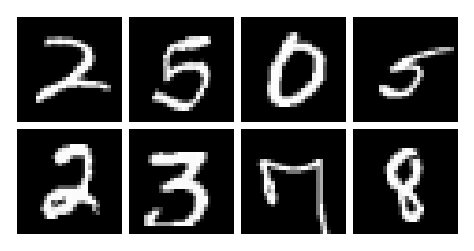

In [21]:
def show_imgs(imgs, row_count=4):
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    nrow = min(num_imgs, row_count)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128)
    imgs = imgs.clamp(min=0, max=1)
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    plt.show()

show_imgs([train_set[i][0] for i in range(8)])

# Assignment 1

The first class we implement is a standard MLP for generating the translation and scaling factors $s_\theta$ and $m_\theta$.

In [13]:
class MLP(nn.Module):
    def __init__(self, half_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(half_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, half_dim),
            nn.Tanh() # Forces values between -1 and 1
        )

    def forward(self, x):
        return self.net(x)

This class implements a single layer of the flow, guaranteeing mathematical invertibility.
* **Forward Pass (`forward`)**: The input vector is split into two halves using a binary mask. The first half ($x_1$) is left unchanged and passed through two MLPs to compute scale ($s$) and translation ($m$) parameters. These are used to transform the second half ($x_2$). The log-determinant of this step simplifies to the sum of the scale parameters.
* **Inverse Pass (`inverse`)**: Because $x_1$ remains identical during the forward pass, we can feed it back into the MLPs to recover the exact scale and translation values. We then use standard inverse algebra to perfectly reconstruct $x_2$.

In [14]:
class CouplingLayer(nn.Module):
    def __init__(self, dim, mask):
        super().__init__()
        self.register_buffer('mask', mask)
        half_dim = mask.sum().item()
        
        self.s_net = MLP(half_dim)
        self.m_net = MLP(half_dim)

    def forward(self, x):
        x1 = x[:, self.mask]
        x2 = x[:, ~self.mask]
        
        s = self.s_net(x1)
        m = self.m_net(x1)
        
        x2_prime = x2 * torch.exp(s) + m
        
        z = torch.empty_like(x)
        z[:, self.mask] = x1
        z[:, ~self.mask] = x2_prime
        
        log_det = s.sum(dim=1)
        return z, log_det

    def inverse(self, z):
        x1_prime = z[:, self.mask]
        x2_prime = z[:, ~self.mask]
        
        s = self.s_net(x1_prime)
        m = self.m_net(x1_prime)
        
        x2 = (x2_prime - m) * torch.exp(-s)
        
        x = torch.empty_like(z)
        x[:, self.mask] = x1_prime
        x[:, ~self.mask] = x2
        
        return x

This class chains the individual coupling layers to form the full generative model.
* **Architecture**: We sequentially stack 10 coupling layers. We alternate the masking pattern at each layer so that dimensions acting as the "controller" in one step become the "modified" dimensions in the next.
* **Training Objective (`calc_nll`)**: We compute the Negative Log-Likelihood (NLL). The input is mapped to a latent vector ($z$), and we evaluate its log-probability under a standard Gaussian prior $\mathcal{N}(0, I)$. We add the accumulated log-determinant from all layers to track how the distribution's volume changes, and minimize the negated sum.
* **Sampling (`sample`)**: To generate synthetic digits, we draw random noise from the Gaussian prior and pass it backward through the `inverse` path of the network.

In [15]:
class NormalizingFlow(nn.Module):
    def __init__(self, dim=784):
        super().__init__()
        self.dim = dim
        self.layers = nn.ModuleList()
        
        for i in range(10):
            # Alternating checkerboard type masking
            mask = (torch.arange(dim) % 2 == (i % 2)) 
            self.layers.append(CouplingLayer(dim, mask))

    def forward(self, x):
        z = x
        sum_log_det = torch.zeros(x.shape[0], device=x.device)
        for layer in self.layers:
            z, log_det = layer(z)
            sum_log_det += log_det
        return z, sum_log_det

    def inverse(self, z, return_intermediates=False):
        x = z
        intermediates = [x.clone()] if return_intermediates else None
        
        for layer in reversed(self.layers):
            x = layer.inverse(x)
            if return_intermediates:
                intermediates.append(x.clone())
                
        if return_intermediates:
            return x, intermediates
        return x

    def calc_nll(self, x):
        z, sum_log_det = self.forward(x)
        prior = torch.distributions.MultivariateNormal(
            torch.zeros(self.dim, device=x.device), 
            torch.eye(self.dim, device=x.device)
        )
        log_prob_z = prior.log_prob(z)
        log_likelihood = log_prob_z + sum_log_det
        return -log_likelihood.mean()

    def sample(self, num_samples, device):
        prior = torch.distributions.MultivariateNormal(
            torch.zeros(self.dim, device=device), 
            torch.eye(self.dim, device=device)
        )
        z = prior.sample((num_samples,))
        with torch.no_grad():
            samples = self.inverse(z)
        return samples

This section optimizes the model weights to map the MNIST data distribution to a standard Gaussian.
* **Data Processing**: The model expects 1D vectors, so the 2D image tensors are flattened to a size of 784 before being passed to the NLL calculation.
* **Optimization**: The model is trained using the Adam optimizer. Gradient clipping (`clip_grad_norm_`) is applied during backpropagation to prevent exploding gradients and maintain numerical stability.
* **Evaluation**: We evaluate the NLL on the validation set at the end of each epoch to monitor learning and prevent overfitting, reporting the final model performance on the unseen test set.

In [16]:
model = NormalizingFlow(dim=784).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
epochs = 30

train_nll_history = []
val_nll_history = []

for epoch in range(epochs):
    model.train()
    train_nll = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        imgs = imgs.view(imgs.shape[0], -1) # Added flatten
        optimizer.zero_grad()
        loss = model.calc_nll(imgs)
        loss.backward()
        # Optional: gradient clipping for stability in NFs
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) 
        optimizer.step()
        train_nll += loss.item()
        
    train_nll_history.append(train_nll / len(train_loader))
    
    model.eval()
    val_nll = 0
    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(device)
            imgs = imgs.view(imgs.shape[0], -1) # Added flatten
            val_nll += model.calc_nll(imgs).item()
    val_nll_history.append(val_nll / len(val_loader))
    print(f"Epoch {epoch+1}: Train NLL: {train_nll_history[-1]:.4f}, Val NLL: {val_nll_history[-1]:.4f}")

# Test Set NLL
test_nll = 0
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        imgs = imgs.view(imgs.shape[0], -1) # Added flatten
        test_nll += model.calc_nll(imgs).item()
print(f"Final Test NLL: {test_nll / len(test_loader):.4f}")

Epoch 1: Train NLL: -915.0825, Val NLL: -1486.9857
Epoch 2: Train NLL: -1653.9378, Val NLL: -1747.5508
Epoch 3: Train NLL: -1828.7072, Val NLL: -1854.9774
Epoch 4: Train NLL: -1919.3792, Val NLL: -1932.2978
Epoch 5: Train NLL: -1982.6254, Val NLL: -1975.5207
Epoch 6: Train NLL: -2030.8315, Val NLL: -2018.8848
Epoch 7: Train NLL: -2069.2436, Val NLL: -2050.1891
Epoch 8: Train NLL: -2101.1615, Val NLL: -2066.7013
Epoch 9: Train NLL: -2126.0313, Val NLL: -2088.5015
Epoch 10: Train NLL: -2149.7580, Val NLL: -2112.6057
Epoch 11: Train NLL: -2169.3219, Val NLL: -2124.9528
Epoch 12: Train NLL: -2186.5260, Val NLL: -2133.4547
Epoch 13: Train NLL: -2202.6726, Val NLL: -2150.3783
Epoch 14: Train NLL: -2216.6720, Val NLL: -2161.4996
Epoch 15: Train NLL: -2229.8952, Val NLL: -2171.6777
Epoch 16: Train NLL: -2241.8611, Val NLL: -2170.7151
Epoch 17: Train NLL: -2252.1986, Val NLL: -2180.3265
Epoch 18: Train NLL: -2263.1016, Val NLL: -2195.3428
Epoch 19: Train NLL: -2272.9147, Val NLL: -2200.4589
Epo

# Assignment 2

Here we show a transformation of 7 different samples from latent space, trying to invert them into coherent digits.

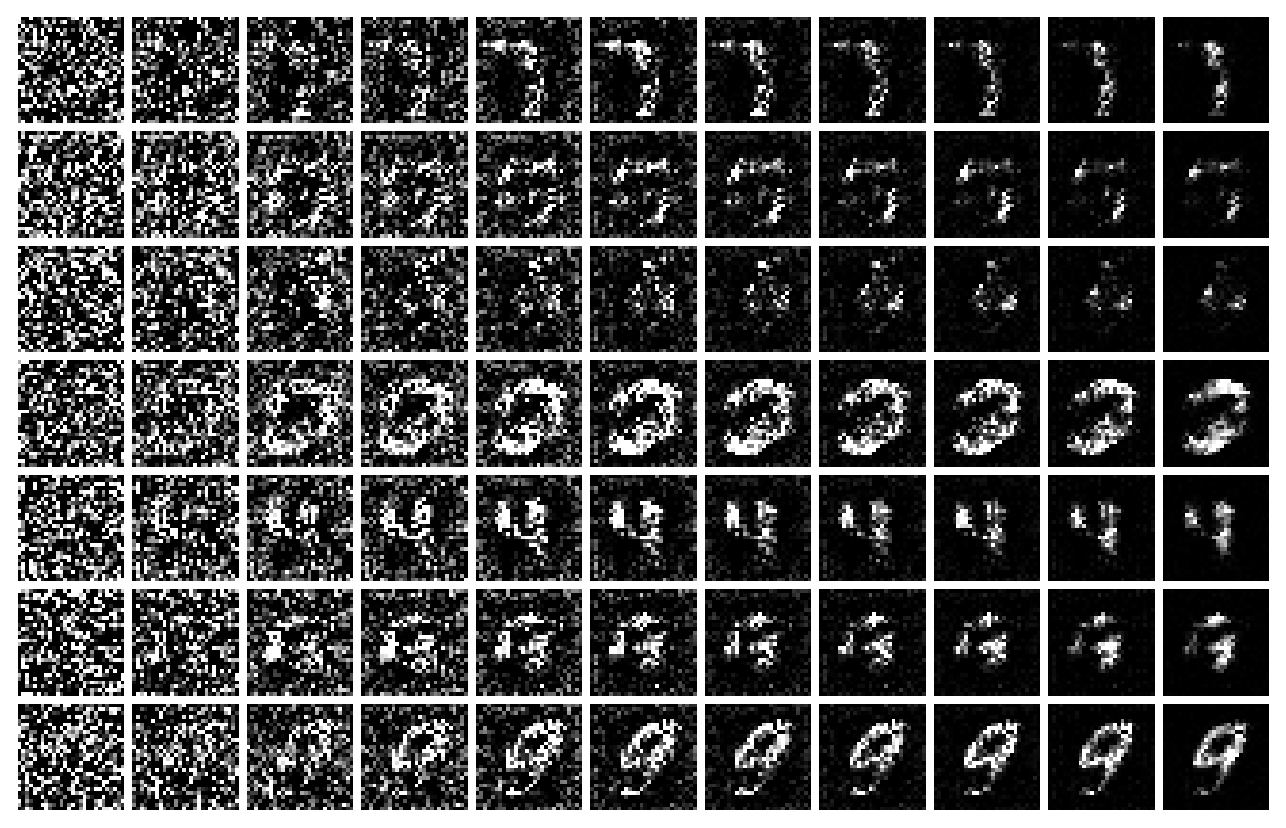

In [ ]:
model.eval()
with torch.no_grad():
    # Sample 7 pure noise vectors
    z_samples = torch.randn(7, 784, device=device)
    _, intermediates = model.inverse(z_samples, return_intermediates=True)
    
    # intermediates is a list of 11 tensors of shape (7, 784)
    grid_images = []
    for batch_step in intermediates:
        grid_images.append(batch_step.view(7, 1, 28, 28))
    
    # Stack the images into a tensor for plotting
    grid_tensor = torch.stack(grid_images, dim=1).view(-1, 1, 28, 28)
    
    show_imgs(grid_tensor, row_count=11)

# Assignment 3

In this section we showcase a traversal from one digit to another by forwarding and inverting them through the network.

Interpolation Pair 1


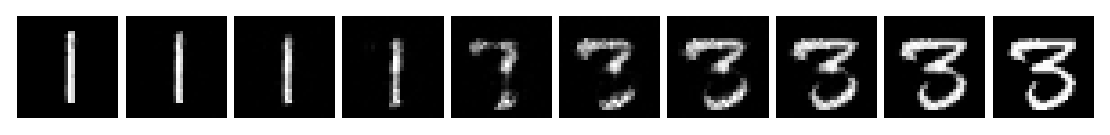

Interpolation Pair 2


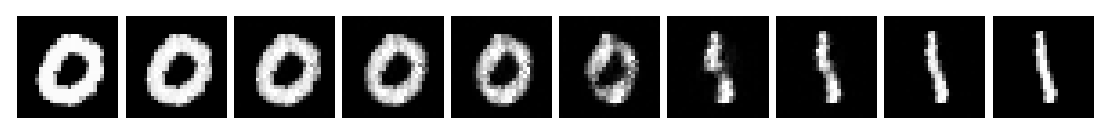

Interpolation Pair 3


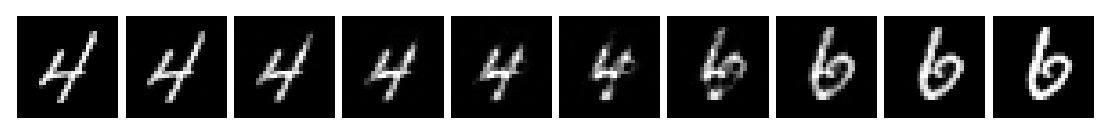

In [ ]:
with torch.no_grad():
    for pair_idx in range(3):
        # Pick two random different digits
        img1 = train_set[random.randint(0, 1000)][0].to(device)
        img2 = train_set[random.randint(1001, 2000)][0].to(device)
        
        # Added flatten for single images
        z1, _ = model.forward(img1.view(1, -1))
        z2, _ = model.forward(img2.view(1, -1))
        
        # Linear interpolation (10 points)
        alphas = torch.linspace(0, 1, steps=10, device=device).unsqueeze(1)
        z_interp = z1 * (1 - alphas) + z2 * alphas
        
        # Decode and display
        imgs_interp = model.inverse(z_interp).view(10, 1, 28, 28)
        print(f"Interpolation Pair {pair_idx+1}")
        show_imgs(imgs_interp, 10)